# STEP 1:
# Research Question

Is there a linear relationship between hours studied and student scores?

# Objectives
1. To examine the relationship between hours studied and student scores.
2. To build a simple linear regression model using hours studied as predictor.
3. To evaluate how well the model predicts student scores.

# Variables
Also include:
- Independent Variable (X): Hours Studied
- Dependent Variable (Y): Student Score

# STEP 2:
# Data Cleaning and EDA

Step 2.1 Import libraries

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


Step 2.2 Load the dataset

If your CSV file is in the same folder as your notebook:

In [51]:
df = pd.read_csv("Student_Performance.csv")
df

,Hours,Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


If you are not sure of the filename, check your folder and use the exact name.

Step 2.3 View the first rows

In [52]:
df.head()

,Hours,Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


This displays the first 5 rows so you can see the structure of the dataset.

Step 2.4 Check dataset information

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours                             10000 non-null  int64 
 1   Scores                            10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


What to look for

Check:

    number of rows
    number of columns
    column names
    data types
    missing values

For the Student Scores dataset, you usually expect:

    Hours
    Scores

Both should be numeric.

Step 2.5 Check summary statistics

In [54]:
df.describe()

,Hours,Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


What this shows

It gives:

    count
    mean
    standard deviation
    minimum
    maximum

This helps you understand the range of values.

Step 2.6 Check for missing values

In [55]:
df.isnull().sum()

Hours                               0
Scores                              0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

If both columns show 0, then there are no missing values.

Step 2.7 Check for duplicates

In [56]:
df.duplicated().sum()

np.int64(127)

If the result is 0, there are no duplicate rows.

If there are duplicates, remove them:

In [57]:
df = df.drop_duplicates()

Step 2.8 Rename columns if needed

Sometimes the dataset column names may vary. For consistency, you can rename them:

In [58]:
df.columns = ["Study Hours", "Previous Scores", "Extracurricular Activities","Sleep Hours","Sample Question Papers Practiced","Performance Index" ]
df.head()

,Study Hours,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


Step 2.9 Exploratory Data Analysis (EDA)

A. Scatter Plot

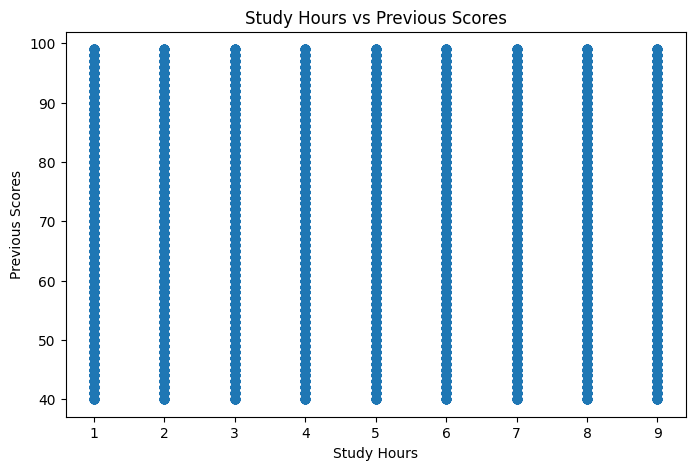

In [59]:
plt.figure(figsize=(8,5))
plt.scatter(df["Study Hours"], df["Previous Scores"])
plt.xlabel("Study Hours")
plt.ylabel("Previous Scores")
plt.title("Study Hours vs Previous Scores")
plt.show()

- The plot shows Study Hours on the x-axis and Previous Scores on the y-axis.

- Each x-value is a vertical column of points, meaning students with the same study hours have a wide range of previous scores.

- That pattern suggests Study Hours alone is not strongly predicting Previous Scores in this dataset.

- If the points do not clearly trend upward from left to right, the relationship is weak or not linear.

- In short: this plot looks like there is little clear correlation between study hours and previous scores.

B. Histogram
- This helps you see the distribution of each variable.

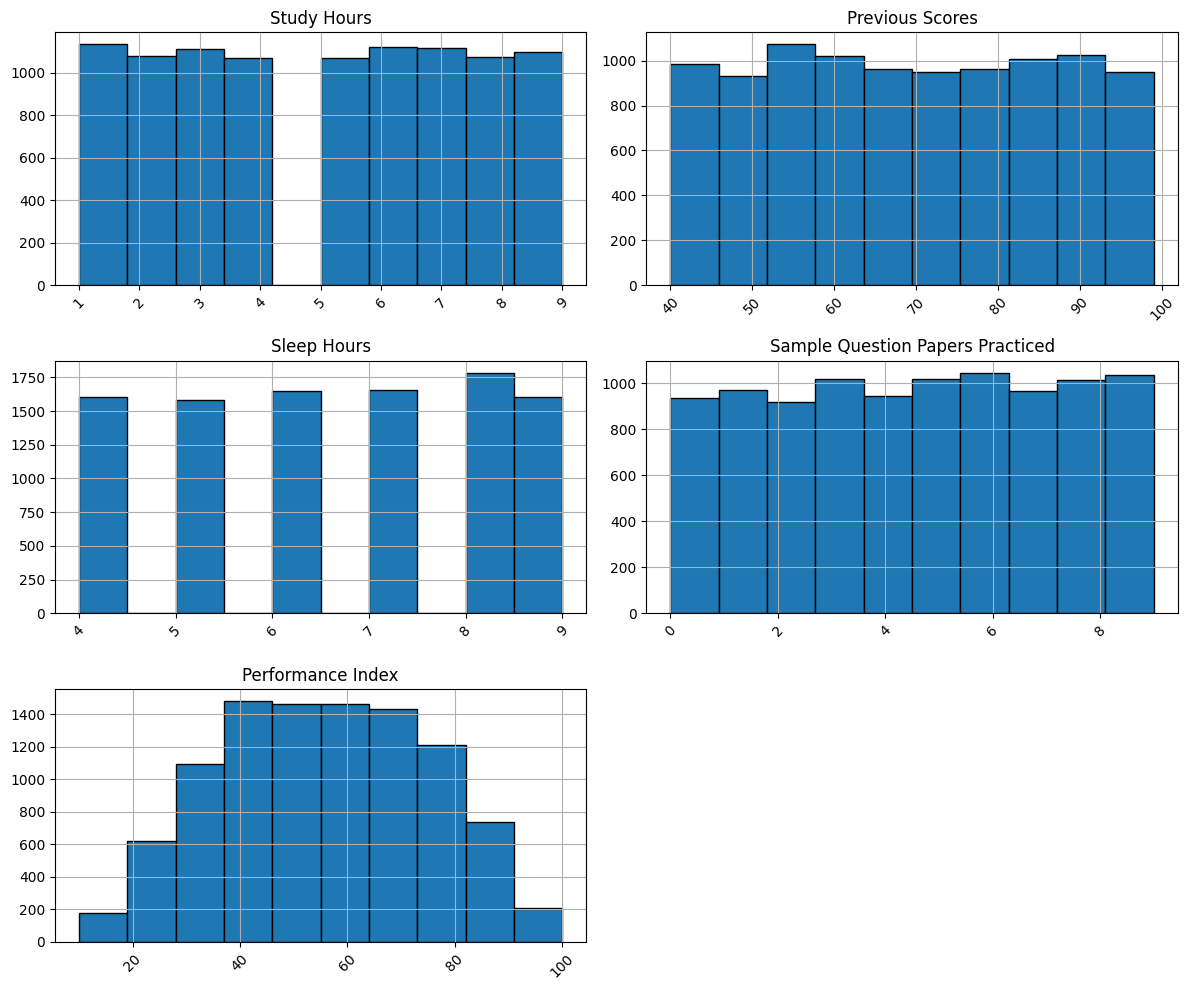

In [60]:
axes = df.hist(figsize=(12,10), layout=(3,2), bins=10, edgecolor='black')
for ax in axes.flatten():
    if ax is None:
        continue
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


- `Study Hours` appears almost evenly distributed across the values 1–9, so students are spread fairly uniformly across study time.
- `Previous Scores` also spans a wide range, with many students scoring between 40 and 100.
- `Sleep Hours` is mostly between 4 and 9 hours, again with a fairly even spread.
- `Sample Question Papers Practiced` is skewed toward the higher values, meaning more students practiced a larger number of papers.
- `Performance Index` looks roughly bell-shaped, with most values clustered in the middle (around 40–70) and fewer at the extremes.
- `Performance Index` has the strongest visible central peak, so it may be the most normally distributed feature.
- `Study Hours` and `Sleep Hours` are not concentrated in one spot, so they may have weaker direct predictive power unless combined with other variables.
- `Sample Question Papers Practiced` being higher for many students could be an important factor to examine in relation to performance.

C. Correlation

In [61]:
df.corr(numeric_only=True)

,Study Hours,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Study Hours,1.000000,-0.010676,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.007975,0.008719,0.915135
Sleep Hours,0.002131,0.007975,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.050352,0.043436,1.000000


If the correlation between Study Hours and Previous Scores is close to 1, that means a strong positive relationship.

# STEP 3
# Model Training

Now we prepare the data and train the regression model.

Step 3.1 Define X and y

In [62]:
X = df[["Study Hours"]]   # predictor must be in double brackets
y = df["Previous Scores"]    # target

- X = independent variable
- y = dependent variable

Step 3.2 Split the data into training and testing sets

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

- test_size=0.2 means 20% of the data will be used for testing
- random_state=42 ensures reproducible results

The dataset was split into training and testing sets so that the model could be trained on one portion of the data and evaluated on unseen data.

Step 3.3 Create the Model

In [64]:
model = LinearRegression()

model = LinearRegression() creates/initializes the linear regression model object.

Purpose:

- sets up the algorithm you want to use,
- prepares default settings (or custom ones if provided), does not learn from data yet.
- Training happens only in the next step: model.fit(X_train, y_train).

Step 3.4 Train the model

In [65]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The purpose of model.fit(X_train, y_train) is to train the regression model.

It learns:
- the intercept (b0)
- the coefficients/slopes (b1, b2, ...) so it can model the relationship between inputs and target (y ≈ b0 + b1x1 + b2x2 + ...) and then make predictions on new data.

This teaches the model the relationship between hours studied and scores.

Step 3.5 View the regression equation

In [66]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 69.623435238166
Slope: -0.05883420893679965


The equation is: 
![alt text](image.png)

Where:
- b0 = intercept
- b1 = slope

The slope indicates how much the predicted score increases for every additional hour studied.

y = 69.6234−0.0588x
- b0 (intercept) = 69.6234
- b1 (slope) = -0.0588

Meaning:

- When x = 0, predicted y is about 69.62.
- Each +1 increase in x lowers predicted y by about 0.059.
- The slope is very close to 0, so the linear effect is very weak.


Step 3.6 Make predictions

In [67]:
y_pred = model.predict(X_test)

Step 3.7 Compare actual and predicted values

In [68]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results

,Actual,Predicted
0,64,69.388098
1,90,69.211596
2,73,69.270430
3,43,69.446933
4,76,69.093927
...,...,...
1970,42,69.505767
1971,60,69.446933
1972,99,69.505767
1973,94,69.211596


# STEP 4
# Performance Evaluation

Now evaluate how well the model performed.

Step 4.1 Compute evaluation metrics

In [72]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 15.052952303136136
MSE: 303.41078529107165
RMSE: 17.418690688196737
R²: -0.0007798225609456644


Step 4.2 Understand the metrics

Model Evaluation Metrics

Why These Metrics Matter

- **MAE (Mean Absolute Error)**: Average absolute prediction error.  
  Purpose: tells us, in target units, how wrong predictions are on average.

- **MSE (Mean Squared Error)**: Average squared prediction error.  
  Purpose: penalizes larger errors more strongly than MAE.

- **RMSE (Root Mean Squared Error)**: Square root of MSE.  
  Purpose: gives error size in the same units as the target, while still emphasizing large errors.

- **R² (Coefficient of Determination)**: Proportion of variance explained by the model.  
  Purpose: measures how well the model performs compared to predicting the mean.

Results

- **MAE:** `15.0529`
- **MSE:** `303.4108`
- **RMSE:** `17.4187`
- **R²:** `-0.0008`

Interpretation

- The model is off by about **15 points** on average (**MAE**).
- Typical error is around **17.4 points** (**RMSE**), with some larger misses.
- **R² is negative**, which means this model performs slightly worse than a baseline model that always predicts the average target value.

Conclusion

This is a **very weak linear model** for the chosen feature-target pair.  
The predictor likely has little to no useful linear relationship with the target.


Step 4.3 Visualize regression line

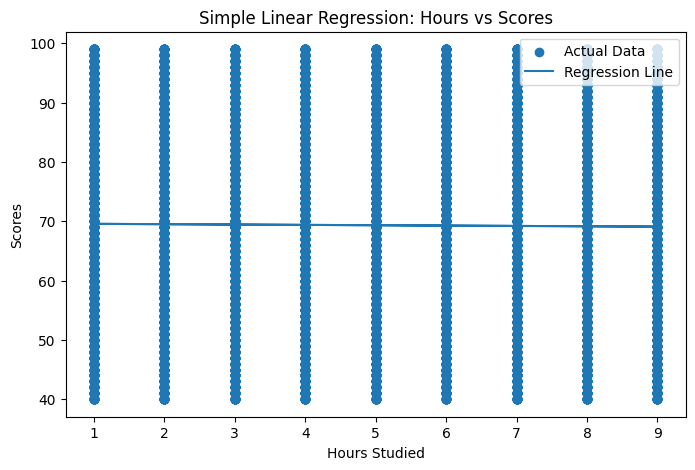

In [73]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")
plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.title("Simple Linear Regression: Hours vs Scores")
plt.legend()
plt.show()

This plot shows almost no linear relationship between Hours Studied and Scores.

- The points form vertical bands at each hour (1–9), and each band spans nearly the full score range (~40–100).
- The regression line is nearly flat around ~69, so predicted score is almost constant regardless of hours studied.
- The model learned a slope near zero, so Hours is not a useful standalone predictor of Scores here.

Step 4.4 Test with a new value

For example, predict the score of a student who studies for 6.5 hours:

In [75]:
new_hours = pd.DataFrame({"Study Hours": [6.5]})
predicted_score = model.predict(new_hours)
print("Predicted Score:", predicted_score[0])

Predicted Score: 69.2410128800768


Based on the trained model, a student who studies for 6.5 hours is predicted to receive approximately a score of 69.24

Step 4.5 Export the trained model

After training, you can save the model so it can be reused later without retraining.

- `pickle` stores the trained `LinearRegression` object in a `.pkl` file.
- You can load this file in another Python script, notebook, or app for future predictions.

In [ ]:
%pip install pandas scikit-learn

import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

dataset_path = "Student_Performance.csv"
export_path = "student_scores_model.pkl"

if "model" not in globals():
    # If the trained model is not already available in this session, train it first.
    if "df" not in globals():
        df = pd.read_csv(dataset_path)

    rename_map = {
        "Hours": "Study Hours",
        "Scores": "Previous Scores",
    }
    df = df.rename(columns=rename_map)

    X = df[["Study Hours"]]
    y = df["Previous Scores"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")